<a href="https://colab.research.google.com/github/heyy-ashwani/Back-Home/blob/main/Hospital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

In [ ]:
# 1. Fetch dataset directly from UCI
print("Downloading dataset...")
diabetes = fetch_ucirepo(id=296)

X = diabetes.data.features
y = diabetes.data.targets['readmitted']

# 2. Convert target to Binary (1 = Readmitted < 30 days, 0 = No/ > 30 days)
y_binary = (y == '<30').astype(int)

# 3. Clean up the features
# Drop columns with massive missing data or irrelevant IDs
cols_to_drop = ['weight', 'payer_code', 'medical_specialty', 'encounter_id', 'patient_nbr']
X = X.drop(columns=[col for col in cols_to_drop if col in X.columns])

# Separate numeric and categorical column names for the pipeline
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# 4. Split the data (80% train, 20% test)
# We use stratify to maintain the same ratio of readmissions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"Dataset successfully loaded! Training set size: {X_train.shape}")

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Dataset successfully loaded! Training set size: (81412, 44)


In [ ]:
# 1. Define preprocessing steps
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 2. Define the model
# class_weight='balanced' forces the algorithm to pay more attention to the minority class (readmissions)
# C=1.0 is the inverse of regularization strength (Standard L2 setup)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='liblinear',
        class_weight='balanced',
        random_state=42,
        max_iter=500
    ))
])

# 3. Train the model
print("Training the L2 Logistic Regression model... (This may take a minute)")
model.fit(X_train, y_train)
print("Training complete!")

Training the L2 Logistic Regression model... (This may take a minute)
Training complete!


ROC-AUC Score: 0.6422

Classification Report:
               precision    recall  f1-score   support

Safe (No/<30)       0.92      0.66      0.77     18083
At Risk (<30)       0.17      0.55      0.26      2271

     accuracy                           0.64     20354
    macro avg       0.54      0.60      0.51     20354
 weighted avg       0.84      0.64      0.71     20354



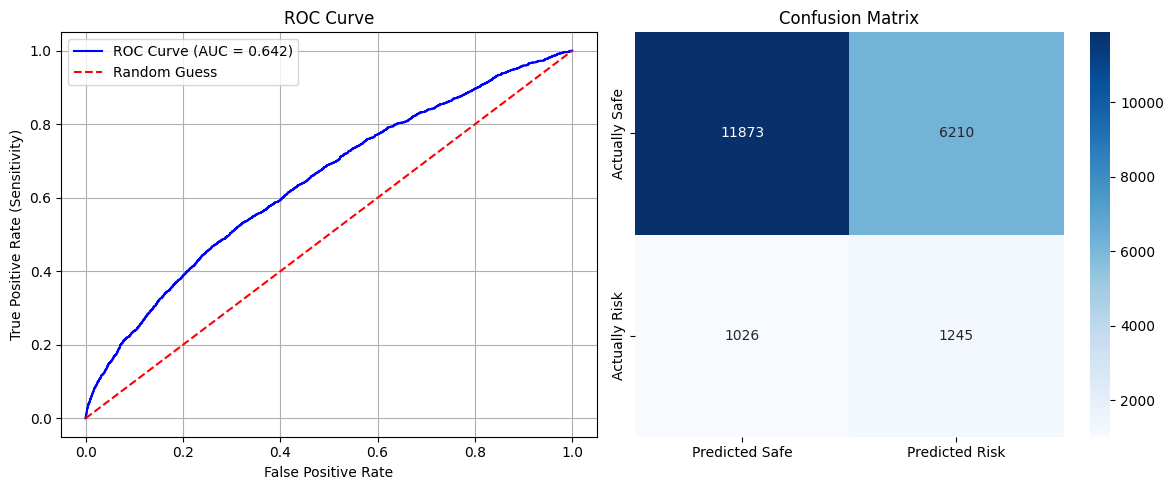

In [ ]:
# 1. Generate predictions and probabilities
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of class 1 (<30 days)

# 2. Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

# 3. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Safe (No/<30)", "At Risk (<30)"]))

# 4. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

# 5. Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicted Safe", "Predicted Risk"],
            yticklabels=["Actually Safe", "Actually Risk"])
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()